In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
from scipy.stats import wasserstein_distance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import plot_utils as plot 
import numpy as np

In [2]:
nextgems_1990_2020_forecasts_equiangular_wp_cons_z128 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_test_only_forecasts/z64_hierarchical.zarr').astype(np.float32)
nextgems_2049_forecasts_equiangular_wp_cons_z128 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2046_2049_equiangular_with_poles_conservative_forecasts/z64_hierarchical.zarr', decode_timedelta=True).astype(np.float32)

nextgems_historical_truth_equiangular_wp_cons = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative/fields.zarr').astype(np.float32)
nextgems_future_truth_equiangular_wp_cons = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2046_2049_equiangular_with_poles_conservative/fields.zarr').astype(np.float32)


Select one variable:

In [3]:
import pickle
load=True

In [4]:
min_max_values = []
if not load:
    for i in range(len(plot.KEY_VARIABLES)):
        display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
        truth_historical = nextgems_historical_truth_equiangular_wp_cons[variable].sel(time=slice("1990", "2015"))
        if (plevel):
            truth_historical = truth_historical.sel(level=plevel)
        max_value = truth_historical.max().values
        min_value = truth_historical.min().values
        print(max_value)
        min_max_values.append((min_value, max_value))
    # Save
    with open("min_max_values.pkl", "wb") as f:
        pickle.dump(min_max_values, f)
else:
    with open("min_max_values.pkl", "rb") as f:
        min_max_values = pickle.load(f)
    print(min_max_values)

[(array(42170.03, dtype=float32), array(59404.508, dtype=float32)), (array(211.42941, dtype=float32), array(315.5887, dtype=float32)), (array(3.102259e-07, dtype=float32), array(0.01486212, dtype=float32)), (array(187.46138, dtype=float32), array(324.652, dtype=float32)), (array(-67.63451, dtype=float32), array(56.132847, dtype=float32)), (array(-53.600014, dtype=float32), array(54.137543, dtype=float32)), (array(0., dtype=float32), array(0.08737123, dtype=float32))]


In [5]:
exceeding = []
if not load:
    for i in range(len(plot.KEY_VARIABLES)):
        display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
        truth_future = nextgems_future_truth_equiangular_wp_cons[variable]
        if (plevel):
            truth_future = truth_future.sel(level=plevel)
        truth_future = truth_future.compute()
        (minv, maxv) = min_max_values[i]
        truth_exceeding_positive = truth_future.where(truth_future > maxv, drop=True)
        truth_exceeding_negative = truth_future.where(truth_future < minv, drop=True)
        exceeding.append({'positive': truth_exceeding_positive, 'negative': truth_exceeding_negative})
    # Save to file
    with open("exceeding.pkl", "wb") as f:
        pickle.dump(exceeding, f)
else:
    with open("exceeding.pkl", "rb") as f:
        exceeding = pickle.load(f)
    

In [6]:
#for i in range(len(plot.KEY_VARIABLES)):
for i in [0]:
    display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
    exceeding[i]['positive_list'] = []
    exceeding[i]['negative_list'] = []
    ds_pos = exceeding[i]['positive']
    for t in ds_pos.time:
        data_t = ds_pos.sel(time=t)
        for lat in data_t.latitude:
            for lon in data_t.longitude:
                data_val = data_t.sel(latitude=lat, longitude=lon).values
                if not str(data_val) == 'nan':
                    exceeding[i]['positive_list'].append({'time':t.values, 'lat':lat.values,'lon':lon.values, 'val':data_val})
    print(f'Eval for var {display_name}')
    num_pos_exceed = len(exceeding[i]["positive_list"])
    print(f'Exceeding positive: {num_pos_exceed}')
    if num_pos_exceed > 0:
        print(f'Max exceedance: +{max([x["val"] for x in exceeding[i]["positive_list"]]) - min_max_values[i][1]:.5f}{unit}')

    break
    ds_neg = exceeding[i]['negative']
    for t in ds_neg.time:
        data_t = ds_neg.sel(time=t)
        for lat in data_t.latitude:
            for lon in data_t.longitude:
                data_val = data_t.sel(latitude=lat, longitude=lon).values
                if not str(data_val) == 'nan':
                    exceeding[i]['negative_list'].append({'time':t.values, 'lat':lat.values,'lon':lon.values, 'val':data_val})

Eval for var Geopotential at 500hPa
Exceeding positive: 85
Max exceedance: +152.32031m^2/s^2


In [25]:
import numpy as np
import pandas as pd
from tqdm import tqdm

for i in [0]:
    display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
    exceeding[i]['positive_list'] = []
    exceeding[i]['negative_list'] = []

    # --- Handle positive dataset ---
    ds_pos = exceeding[i]['positive']
    data_pos = ds_pos.values  # shape: (time, lon, lat)
    times = ds_pos.time.values
    lats = ds_pos.latitude.values
    lons = ds_pos.longitude.values

    valid_mask = ~np.isnan(data_pos)  # shape (T, L, M)

    # Mask out any lat/lon that are not *fully valid* at that timestamp
    for t_i, valid_t in tqdm(enumerate(valid_mask)):

        # Apply mask to data
        vals = data_pos[t_i][valid_t]
        if vals.size == 0:
            continue
        

        lon_idx, lat_idx = np.where(valid_t)
        t_vals = t_val = times[t_i]

        # Vectorized append
        exceeding[i]['positive_list'].extend([
            {'time': t_val, 'lon': lons[lo], 'lat': lats[la], 'val': v}
            for la, lo, v in zip(lat_idx, lon_idx, vals)
        ])

    print(f'Eval for var {display_name}')
    num_pos_exceed = len(exceeding[i]['positive_list'])
    print(f'Exceeding positive: {num_pos_exceed}')
    if num_pos_exceed > 0:
        vals = [x['val'] for x in exceeding[i]['positive_list']]
        max_exceed = max(vals) - min_max_values[i][1]
        print(f'Max exceedance: +{max_exceed:.5f}{unit}')


21it [00:00, 32695.02it/s]

Eval for var Geopotential at 500hPa
Exceeding positive: 85
Max exceedance: +152.32031m^2/s^2


In [7]:
for i in range(len(plot.KEY_VARIABLES)):
    display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
    print(f'Eval for var {display_name}')
    num_pos_exceed = len(exceeding[i]["positive_list"])
    print(f'Exceeding positive: {num_pos_exceed}')
    if num_pos_exceed > 0:
        print(f'Max exceedance: +{max([x["val"] for x in exceeding[i]["positive_list"]]) - min_max_values[i][1]:.5f}{unit}')
    num_neg_exceed = len(exceeding[i]["negative_list"])
    print(f'Exceeding negative: {num_neg_exceed}')
    if num_neg_exceed > 0:
        print(f'Min exceedance: {min([x["val"] for x in exceeding[i]["negative_list"]]) - min_max_values[i][0]:.2f}{unit}')
    print('#'*20)
    print('')

Eval for var Geopotential at 500hPa
Exceeding positive: 85
Max exceedance: +152.32031m^2/s^2
Exceeding negative: 0
####################

Eval for var Temperature at 850hPa
Exceeding positive: 25
Max exceedance: +1.40396K
Exceeding negative: 0
####################

Eval for var Specific humidity at 700hPa
Exceeding positive: 158
Max exceedance: +0.00137kg/kg
Exceeding negative: 0
####################

Eval for var T2m
Exceeding positive: 55
Max exceedance: +1.99921K
Exceeding negative: 0
####################

Eval for var U-component of wind at 850hPa
Exceeding positive: 0
Exceeding negative: 0
####################

Eval for var V-component of wind at 850hPa
Exceeding positive: 0
Exceeding negative: 1
Min exceedance: -2.21m/s
####################

Eval for var Total precipiation (6hr)
Exceeding positive: 0
Exceeding negative: 0
####################



In [ ]:
i =0
points = 0
diffs = []
for t in truth_exceeding_positive.time:
    data_t = truth_exceeding_positive.sel(time=t)
    # Plot map
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()


    # Add map features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.COASTLINE)

    for lat in data_t.latitude:
        for lon in data_t.longitude:
            data_val = data_t.sel(latitude=lat, longitude=lon).values
            if not str(data_val) == 'nan':
                points = points + 1
                diff = data_val-max_value
                diffs.append(diff)
                ax.plot(lon, lat, marker="o", markersize=3, transform=ccrs.PlateCarree(), label='+' + str(diff))
                #ax.text(lon + 3, lat, '+' + str(data_val-max_value), transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

    ax.set_title(str(t.values)[:13] + f' - {variable}', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/exceeding_values_2049/positive/{variable}_{i}", dpi=400, bbox_inches='tight',)
    i = i+1

In [24]:
def get_temporal_index_in_dataset(timestamp, ds):
    # Suppose your timestamp is
    target_time = timestamp
    
    # get the index object from the DataArray
    time_index = ds.get_index("time")
    
    # find the integer position
    idx = time_index.get_loc(target_time)
    return idx

def get_true_data_matching_forecast_timestamps(ds_forecast, ds_truth, prediction_steps):
    '''
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    '''
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth) + prediction_steps + 1
    idx_truth_last = get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth) + prediction_steps + 1
    new_forecast = ds_forecast.copy().isel(prediction_timedelta=prediction_steps)
    new_truth = ds_truth.isel(time=slice(idx_truth_first, idx_truth_last + 1)).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.assign_coords({'time': new_truth['time']})
    return new_forecast, new_truth

In [26]:
# for i in range(len(plot.KEY_VARIABLES)):
i = 0
display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
current_ds_forecast = nextgems_2049_forecasts_equiangular_wp_cons_z128[variable]
current_ds_truth = nextgems_future_truth_equiangular_wp_cons[variable]
if plevel:
    current_ds_forecast = current_ds_forecast.sel(level=plevel)
    current_ds_truth = current_ds_truth.sel(level=plevel)
new_forecast, new_truth = get_true_data_matching_forecast_timestamps(current_ds_forecast, current_ds_truth, 0)
print(new_forecast.isel(time=0).time)
print(new_truth.isel(time=0).time)

<xarray.DataArray 'time' ()> Size: 8B
array('2046-01-01T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    level                 int64 8B 500
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000006
    time                  datetime64[ns] 8B 2046-01-01T12:00:00
<xarray.DataArray 'time' ()> Size: 8B
array('2046-01-01T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    level    int64 8B 500
    time     datetime64[ns] 8B 2046-01-01T12:00:00


In [19]:
def get_temporal_index_in_dataset(timestamp, ds):
    # Suppose your timestamp is
    target_time = timestamp
    
    # get the index object from the DataArray
    time_index = ds.get_index("time")
    
    # find the integer position
    idx = time_index.get_loc(target_time)
    return idx

def get_true_data_matching_forecast_timestamps(ds_forecast, ds_truth, prediction_steps):
    '''
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    '''
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth) + prediction_steps + 1
    idx_truth_last = get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth)
    return ds_truth.isel(time=slice(idx_truth_first, idx_truth_last))

SyntaxError: incomplete input (1924929633.py, line 16)

In [23]:
print(f"{points} points exceeding for {variable}")
print(str(max(diffs))+unit)

NameError: name 'points' is not defined

In [25]:
truth_future_0_12 = truth_future.sel(time=truth_future.time.dt.hour.isin([0, 12]))
truth_future_6_18 = truth_future.sel(time=truth_future.time.dt.hour.isin([6, 18]))

In [29]:
i =0
points = 0
for t in truth_exceeding_negative.time:
    data_t = truth_exceeding_negative.sel(time=t)
    # Plot map
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()


    # Add map features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.COASTLINE)

    for lat in data_t.latitude:
        for lon in data_t.longitude:
            data_val = data_t.sel(latitude=lat, longitude=lon).values
            if not str(data_val) == 'nan':
                points = points + 1
                ax.plot(lon, lat, marker="o", markersize=3, transform=ccrs.PlateCarree(), label='-' + str(abs(min_value) - abs(data_val)))
                #ax.text(lon + 3, lat, '+' + str(data_val-max_value), transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

    ax.set_title(str(t.values)[:13] + f' - {variable}', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/exceeding_values_2049/negative/{variable}_{i}", dpi=400)
    i = i+1

In [30]:
print(f"{points} points exceeding negative for {variable}")

0 points exceeding negative for 2m_temperature


In [23]:
# Suppose your timestamp is
target_time = truth_exceeding_positive.time[0].values

# get the index object from the DataArray
time_index = truth_future.get_index("time")
print(time_index)


# find the integer position
print(target_time)
idx = time_index.get_loc(target_time)
print(idx)
print(forecast_future.get_index("time")[idx])

DatetimeIndex(['2049-01-01 00:00:00', '2049-01-01 12:00:00',
               '2049-01-02 00:00:00', '2049-01-02 12:00:00',
               '2049-01-03 00:00:00', '2049-01-03 12:00:00',
               '2049-01-04 00:00:00', '2049-01-04 12:00:00',
               '2049-01-05 00:00:00', '2049-01-05 12:00:00',
               ...
               '2049-12-27 00:00:00', '2049-12-27 12:00:00',
               '2049-12-28 00:00:00', '2049-12-28 12:00:00',
               '2049-12-29 00:00:00', '2049-12-29 12:00:00',
               '2049-12-30 00:00:00', '2049-12-30 12:00:00',
               '2049-12-31 00:00:00', '2049-12-31 12:00:00'],
              dtype='datetime64[ns]', name='time', length=730, freq=None)
2049-07-11T12:00:00.000000000
383
2049-07-11 18:00:00


In [ ]:
idx = nextgems_future_truth_equiangular_wp_cons.get_index("time").get_loc(target_time)
print(nextgems_future_truth_equiangular_wp_cons[variable].sel(level=plevel).isel(time=slice(idx, idx+40)))

<xarray.DataArray 'temperature' (time: 40, longitude: 128, latitude: 64)> Size: 1MB
dask.array<getitem, shape=(40, 128, 64), dtype=float32, chunksize=(34, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      int64 8B 850
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 320B 2049-07-11T12:00:00 ... 2049-07-21T...


In [51]:
print(forecast_future.time[0])

<xarray.DataArray 'time' ()> Size: 8B
array('2049-01-01T06:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    level    int64 8B 850
    time     datetime64[ns] 8B 2049-01-01T06:00:00


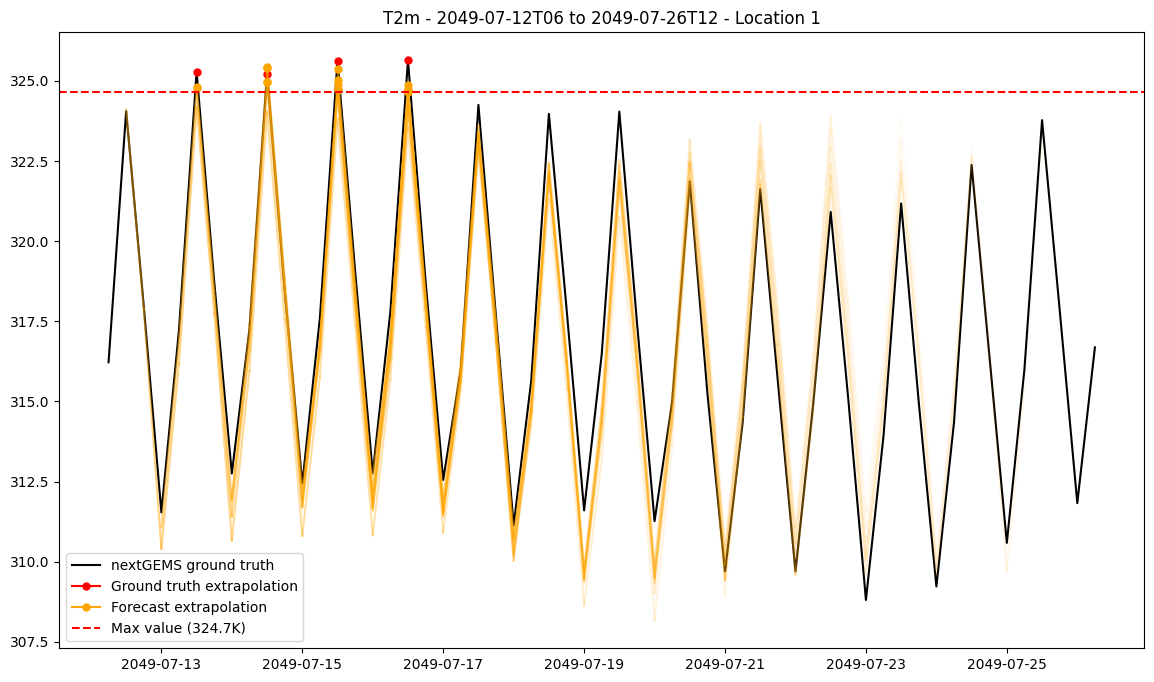

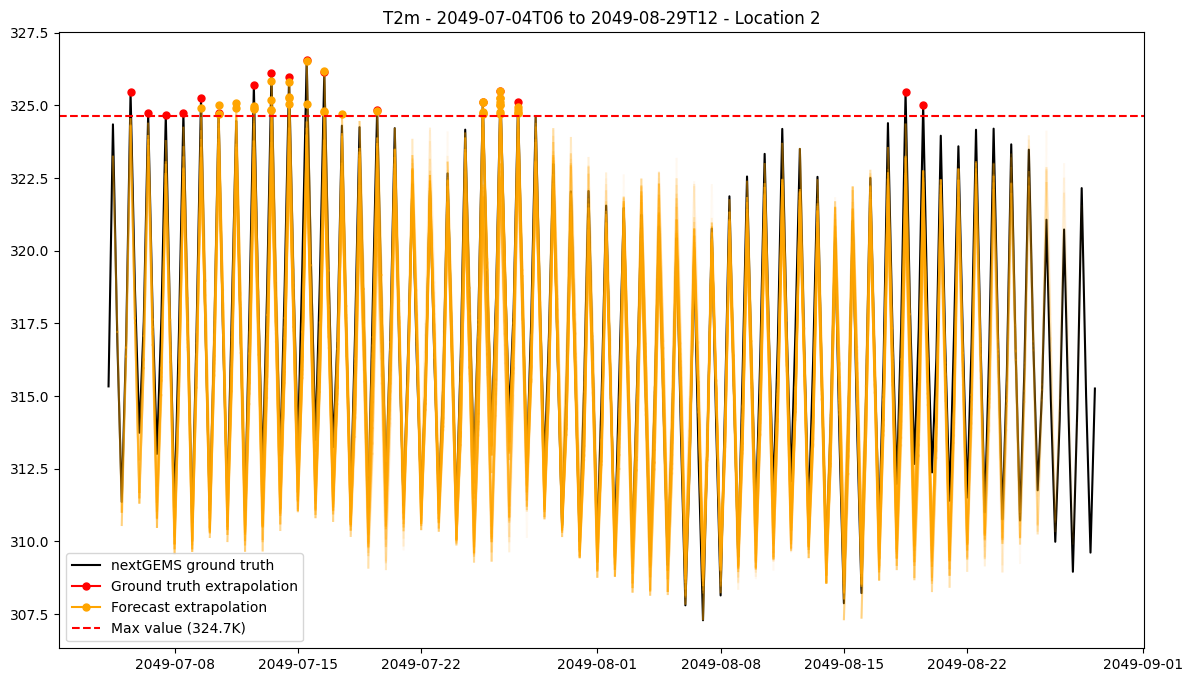

In [ ]:
true_data_full_time = nextgems_future_truth_equiangular_wp_cons.get_index("time")
true_data_time = truth_future.get_index("time")
alpha_base=0.5
locs = []
lon=truth_exceeding_positive.longitude.values[0]
lat=truth_exceeding_positive.latitude.values[0]
j=0
for lon in truth_exceeding_positive.longitude.values:
    for lat in truth_exceeding_positive.latitude.values:
        
        
        not_nan_times = []
        for t in truth_exceeding_positive.time.values:
            data_val = truth_exceeding_positive.sel(latitude=lat, longitude=lon, time=t).values
            if not str(data_val) == 'nan':
                not_nan_times.append(t)
        if len(not_nan_times) == 0:
            continue
        idx_first = true_data_full_time.get_loc(not_nan_times[0])
        idx_last = true_data_full_time.get_loc(not_nan_times[-1])
        try:
            forecast_idx = truth_future_6_18.get_index('time').get_loc(truth_future.time.isel(time=idx_first-5).values)
            offset=1
        except Exception:
            forecast_idx = truth_future_6_18.get_index('time').get_loc(truth_future.time.isel(time=idx_first-4).values)
            offset=2
        j = j+1
        locs.append((lon,lat))
        plt.figure(figsize=(14, 8))
        plt.title(f'{display_name} - {str(nextgems_future_truth_equiangular_wp_cons.time.values[idx_first-5])[:13]} to {str(nextgems_future_truth_equiangular_wp_cons.time.values[idx_last+40])[:13]} - Location {j}')
        #plt.plot(nextgems_2049_truth_equiangular_wp_cons.time.values[idx_first-5 : idx_last+40], nextgems_2049_truth_equiangular_wp_cons[variable].sel(level=plevel, longitude=lon, latitude=lat).isel(time=slice(idx_first-5, idx_last+40)), color='black', label='nextGEMS ground truth')
        plt.plot(nextgems_future_truth_equiangular_wp_cons.time.values[idx_first-5 : idx_last+40], nextgems_future_truth_equiangular_wp_cons[variable].sel(longitude=lon, latitude=lat).isel(time=slice(idx_first-5, idx_last+40)), color='black', label='nextGEMS ground truth')
        first_truth=True
        for t in not_nan_times:
            if first_truth:
                #plt.plot(t, nextgems_2049_truth_equiangular_wp_cons[variable].sel(level=plevel, longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5, label='Ground truth extrapolation')
                plt.plot(t, nextgems_future_truth_equiangular_wp_cons[variable].sel(longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5, label='Ground truth extrapolation')
                first_truth=False
            else:
                #plt.plot(t, nextgems_2049_truth_equiangular_wp_cons[variable].sel(level=plevel, longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5)
                plt.plot(t, nextgems_future_truth_equiangular_wp_cons[variable].sel(longitude=lon, latitude=lat, time=t), color='red', marker="o", markersize=5)

        forecast_future_slice = forecast_future.sel(longitude=lon, latitude=lat).isel(time=slice(forecast_idx, forecast_idx+2+ int((idx_last-idx_first)/2)))

        first_model=True
        first_forecast=True
        for t in forecast_future_slice.time:
            time_idx = true_data_time.get_loc(t.values)
            if first_forecast:
                times = truth_future.time[time_idx+1: time_idx+41]
                values = forecast_future_slice.sel(time=t)
                n = len(times)

                for i in range(n):
                    plt.plot(
                        times[i:i+2],  # short segment
                        values[i:i+2],
                        color="orange",
                        alpha=alpha_base - (i / n)*alpha_base,   # alpha decays
                    )
                #plt.plot(truth_future.time[time_idx+1: time_idx+41], forecast_future_slice.sel(time=t), color="orange", alpha=0.2, label='Forecast')
                first_forecast=False
            else:
                #plt.plot(truth_future.time[time_idx+1: time_idx+41], forecast_future_slice.sel(time=t), color="orange", alpha=0.2)
                times = truth_future.time[time_idx+1: time_idx+41]
                values = forecast_future_slice.sel(time=t)
                n = len(times)

                for i in range(n):
                    plt.plot(
                        times[i:i+2],  # short segment
                        values[i:i+2],
                        color="orange",
                        alpha=alpha_base - (i / n)*alpha_base,   # alpha decays
                    )
            for i, val in enumerate(forecast_future_slice.sel(time=t).values):
                if val > max_value:
                    if first_model:
                        plt.plot(truth_future.time[time_idx+1+i], val, color='orange', marker="o", markersize=5, label='Forecast extrapolation')
                        first_model=False
                    else:
                        plt.plot(truth_future.time[time_idx+1+i], val, color='orange', marker="o", markersize=5)



        #plt.plot(nextgems_2049_truth_equiangular_wp_cons.time.values[idx : idx+40], forecast_future.sel(longitude=lon, latitude=lat).isel(time=idx_forecast-1).values)
        plt.axhline(y=max_value, linestyle='--', color='red', label=f'Max value ({max_value:.1f}{unit})')
        plt.legend()
        plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/max_value_timelines/{variable}_location_{j}", dpi=400, bbox_inches='tight',)
        

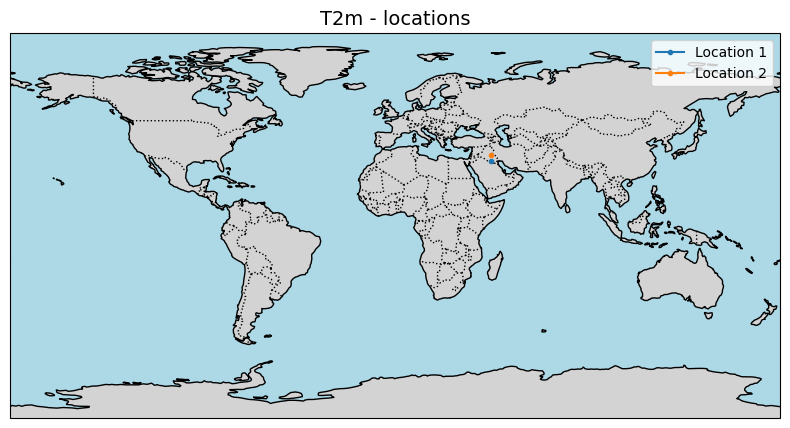

In [28]:
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()


# Add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.COASTLINE)

for i, (lon,lat) in enumerate(locs):
    ax.plot(lon, lat, marker="o", markersize=3, transform=ccrs.PlateCarree(), label=f'Location {i+1}')
    #ax.text(lon + 3, lat, '+' + str(data_val-max_value), transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

ax.set_title(f'{display_name} - locations', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/max_value_timelines/{variable}_locations", dpi=400, bbox_inches='tight',)

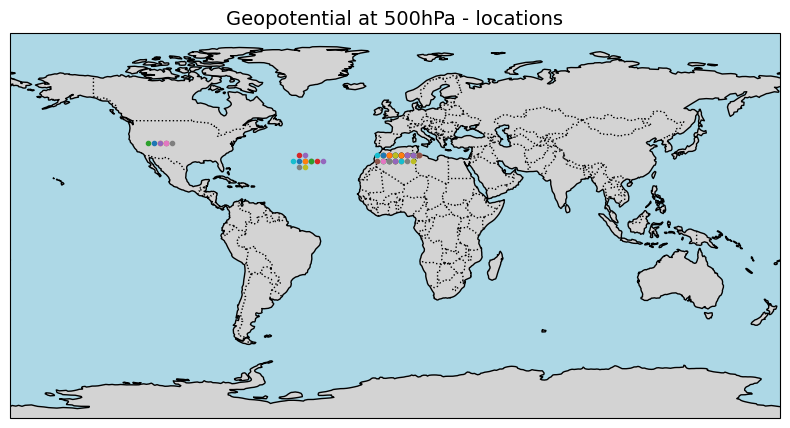

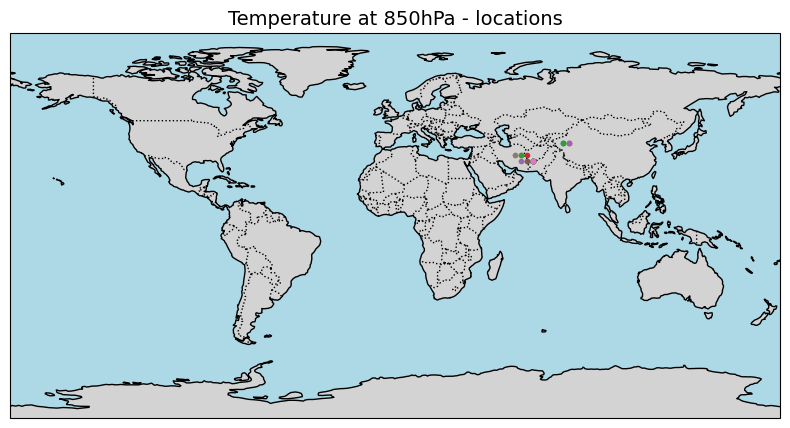

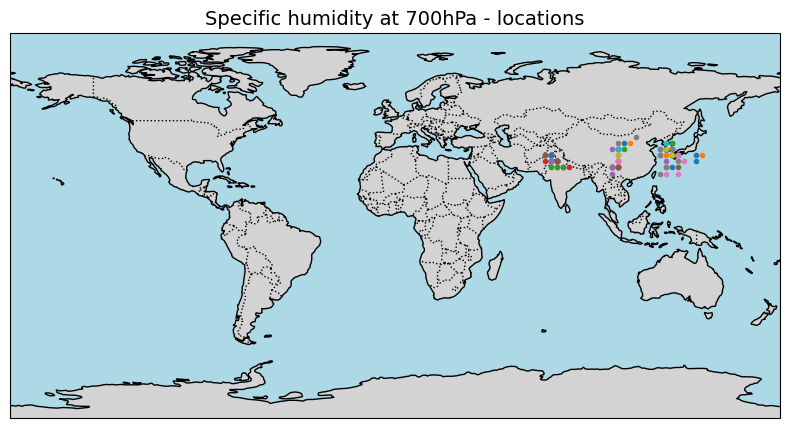

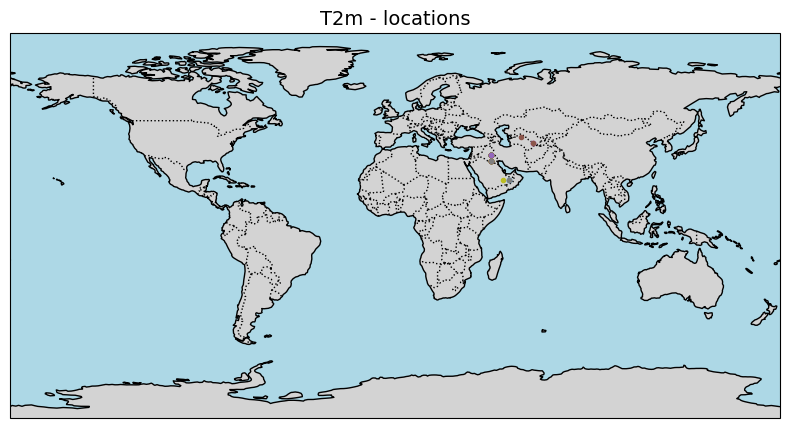

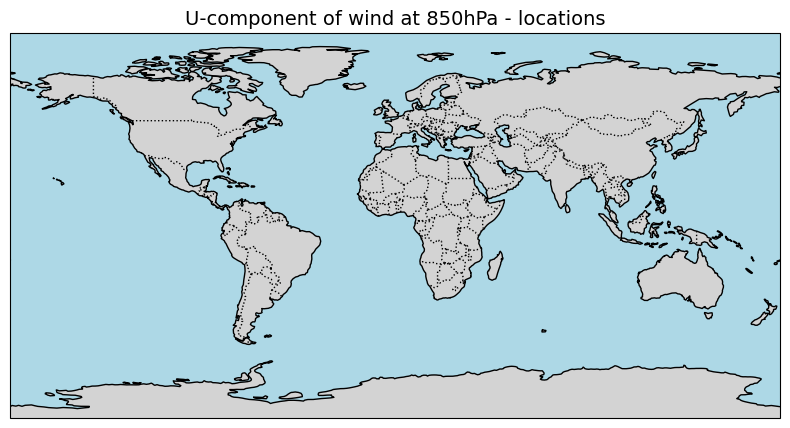

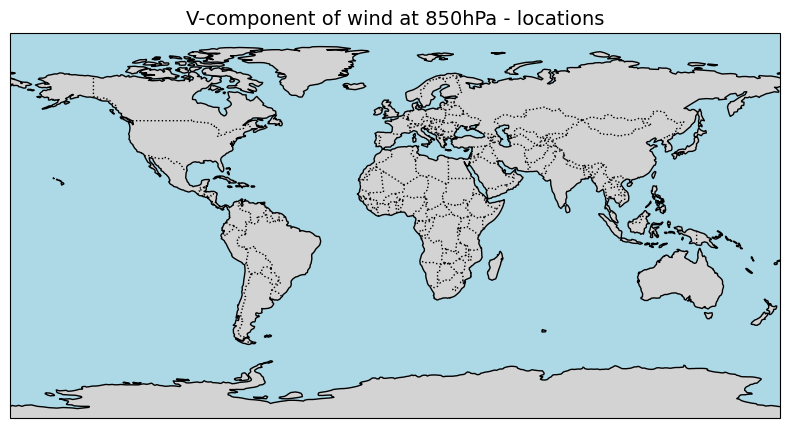

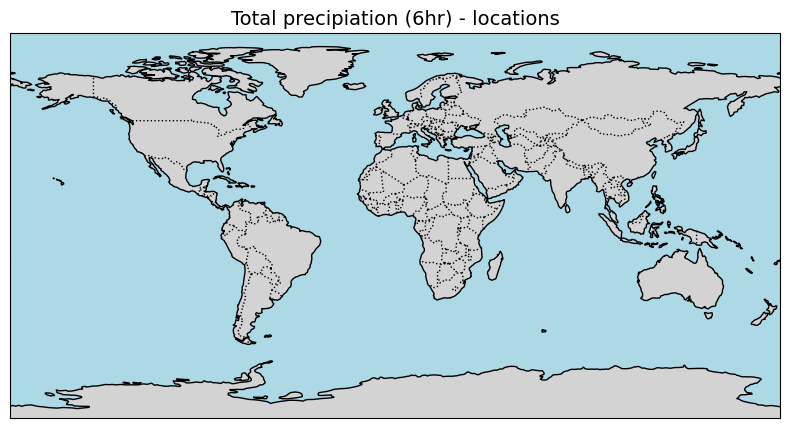

In [43]:
for i in range(len(plot.KEY_VARIABLES)):
    display_name, unit, variable, plevel = plot.KEY_VARIABLES[i]
    unique_locs = {}
    locs = [(x["lon"],x["lat"]) for x in exceeding[i]["positive_list"]]
    for (lon, lat) in locs:
        (slon, slat) = (str(lon), str(lat))
        if not slon in unique_locs.keys():
            unique_locs[slon]=slat
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()


    # Add map features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.COASTLINE)

    for i, (lon,lat) in enumerate(locs):
        ax.plot(lon, lat, marker="o", markersize=3, transform=ccrs.PlateCarree(), label=f'Location {i+1}')
        #ax.text(lon + 3, lat, '+' + str(data_val-max_value), transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

    ax.set_title(f'{display_name} - locations', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/max_value_timelines/{variable}_locations_2046_2049", dpi=400, bbox_inches='tight',)
    